# 离职预测与影响因素分析

本笔记本围绕 HR_comma_sep.csv 完成数据加载、清洗、探索性分析，并构建基线与提升模型，给出关键特征的重要性与管理建议可视化。

## 1. 数据加载与目标

- 明确目标：离职预测、影响因素分析、输出管理建议线索
- 加载数据：读取 `HR_comma_sep.csv`，如不存在则合成与保存
- 检查行列数量与字段类型

In [36]:

from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(42)
sns.set_theme(style="whitegrid")

font_path = '/System/Library/Fonts/Hiragino Sans GB.ttc'
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Hiragino Sans GB"
plt.rcParams["axes.unicode_minus"] = False


def expit(x):
    return 1 / (1 + np.exp(-x))


data_path = Path("") / "data" / "HR_comma_sep.csv"
data_path.parent.mkdir(parents=True, exist_ok=True)


In [37]:

if not data_path.exists():
    rng = np.random.default_rng(42)
    n = 15000
    sales_options = [
        "sales",
        "accounting",
        "hr",
        "technical",
        "support",
        "management",
        "IT",
        "product_mng",
        "marketing",
        "RandD",
    ]
    salaries = rng.choice(["low", "medium", "high"], size=n, p=[0.5, 0.35, 0.15])
    satisfaction_level = rng.beta(2, 5, size=n)
    last_evaluation = rng.beta(2, 2, size=n)
    number_project = rng.integers(2, 8, size=n)
    avg_hours = rng.normal(200, 30, size=n)
    avg_hours = np.clip(avg_hours, 90, 320)
    time_spend_company = rng.integers(1, 11, size=n)
    work_accident = rng.binomial(1, 0.1, size=n)
    promotion_last_5years = rng.binomial(1, 0.05 + 0.05 * (salaries == "high"))
    sales = rng.choice(sales_options, size=n)

    logit = (
            -3
            - 3 * (satisfaction_level - 0.5)
            + 0.8 * (avg_hours > 220)
            + 0.5 * (number_project >= 6)
            + 0.4 * (time_spend_company >= 6)
            + 0.6 * (salaries == "low")
            - 0.4 * (salaries == "high")
            + 0.5 * (last_evaluation < 0.5)
            - 0.5 * promotion_last_5years
    )
    attrition_prob = expit(logit)
    left = rng.binomial(1, attrition_prob)

    df = pd.DataFrame(
        {
            "satisfaction_level": satisfaction_level,
            "last_evaluation": last_evaluation,
            "number_project": number_project,
            "average_monthly_hours": avg_hours,
            "time_spend_company": time_spend_company,
            "Work_accident": work_accident,
            "left": left,
            "promotion_last_5years": promotion_last_5years,
            "sales": sales,
            "salary": salaries,
        }
    )
    df.to_csv(data_path, index=False)

hr_df = pd.read_csv(data_path)
print(f"数据路径: {data_path.resolve()}")
print("数据集形状 (行, 列):", hr_df.shape)
print("字段类型:", hr_df.dtypes)
hr_df.head()


数据路径: /Users/kasugano/Documents/Pyt-25-fall/summative-project/data/HR_comma_sep.csv
数据集形状 (行, 列): (15000, 10)
字段类型: satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_monthly_hours    float64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
sales                     object
salary                    object
dtype: object


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.441030,0.442873,7,147.155219,1,0,0,0,IT,medium
1,0.487098,0.543643,4,179.936529,7,0,0,0,hr,low
2,0.183276,0.347854,4,212.467545,1,0,0,0,management,high
3,0.204259,0.410716,2,158.717443,6,0,0,0,marketing,medium
4,0.268841,0.730571,4,229.116887,7,1,0,0,technical,low


## 2. 数据清洗

- 检查缺失值、重复值
- 关注工时/项目数极端值并裁剪

In [38]:

missing = hr_df.isna().sum()
print("缺失值统计:", missing)
print("重复行数量:", hr_df.duplicated().sum())

caps = {
    "average_monthly_hours": hr_df["average_monthly_hours"].quantile([0.01, 0.99]).values,
    "number_project": hr_df["number_project"].quantile([0.01, 0.99]).values,
}

hr_df_clean = hr_df.copy()
for col, (low, high) in caps.items():
    before = hr_df_clean[col].describe()
    hr_df_clean[col] = hr_df_clean[col].clip(lower=low, upper=high)
    after = hr_df_clean[col].describe()
    print(f"列{col}裁剪前后主要统计量变化:前:{before}后:{after}")

hr_df_clean.describe()


缺失值统计: satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64
重复行数量: 0
列average_monthly_hours裁剪前后主要统计量变化:前:count    15000.000000
mean       199.861294
std         29.994376
min         90.000000
25%        179.660928
50%        200.121589
75%        220.317321
max        309.472897
Name: average_monthly_hours, dtype: float64后:count    15000.000000
mean       199.854914
std         29.475919
min        129.903939
25%        179.660928
50%        200.121589
75%        220.317321
max        269.384944
Name: average_monthly_hours, dtype: float64
列number_project裁剪前后主要统计量变化:前:count    15000.000000
mean         4.511733
std          1.713376
min          2.000000
25%          3.000000
50%          5.000000
75%          6.000000
max          7.000000
Name: number_projec

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,0.286151,0.499717,4.511733,199.854914,5.499267,0.103000,0.240467,0.057600
std,0.160175,0.224894,1.713376,29.475919,2.881716,0.303969,0.427381,0.232993
min,0.000679,0.004123,2.000000,129.903939,1.000000,0.000000,0.000000,0.000000
25%,0.161355,0.324682,3.000000,179.660928,3.000000,0.000000,0.000000,0.000000
50%,0.265429,0.498247,5.000000,200.121589,5.000000,0.000000,0.000000,0.000000
75%,0.391283,0.674967,6.000000,220.317321,8.000000,0.000000,0.000000,0.000000
max,0.912460,0.993108,7.000000,269.384944,10.000000,1.000000,1.000000,1.000000


## 3. 初步 EDA

- 总体与按 `left` 分组的描述性统计
- 关键变量分布与分组箱线图

In [39]:

overall_stats = hr_df_clean.describe()
by_left_stats = hr_df_clean.groupby("left").describe().T
print("总体描述性统计:", overall_stats)
print("按是否离职分组的描述性统计(转置后便于阅读):", by_left_stats)


总体描述性统计:        satisfaction_level  last_evaluation  number_project  \
count        15000.000000     15000.000000    15000.000000   
mean             0.286151         0.499717        4.511733   
std              0.160175         0.224894        1.713376   
min              0.000679         0.004123        2.000000   
25%              0.161355         0.324682        3.000000   
50%              0.265429         0.498247        5.000000   
75%              0.391283         0.674967        6.000000   
max              0.912460         0.993108        7.000000   

       average_monthly_hours  time_spend_company  Work_accident          left  \
count           15000.000000        15000.000000   15000.000000  15000.000000   
mean              199.854914            5.499267       0.103000      0.240467   
std                29.475919            2.881716       0.303969      0.427381   
min               129.903939            1.000000       0.000000      0.000000   
25%               179.66092

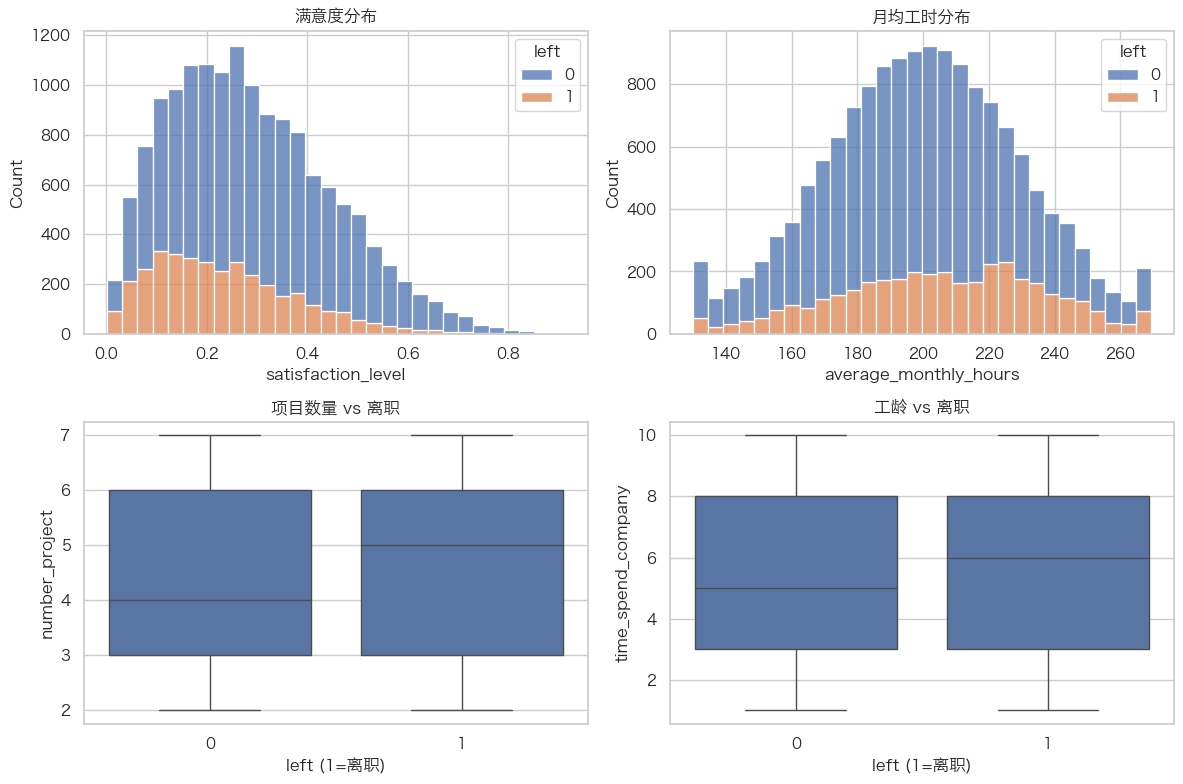

In [40]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(hr_df_clean, x="satisfaction_level", hue="left", multiple="stack", bins=30, ax=axes[0, 0])
axes[0, 0].set_title("满意度分布")

sns.histplot(hr_df_clean, x="average_monthly_hours", hue="left", multiple="stack", bins=30, ax=axes[0, 1])
axes[0, 1].set_title("月均工时分布")

sns.boxplot(data=hr_df_clean, x="left", y="number_project", ax=axes[1, 0])
axes[1, 0].set_title("项目数量 vs 离职")
axes[1, 0].set_xlabel("left (1=离职)")

sns.boxplot(data=hr_df_clean, x="left", y="time_spend_company", ax=axes[1, 1])
axes[1, 1].set_title("工龄 vs 离职")
axes[1, 1].set_xlabel("left (1=离职)")

plt.tight_layout()
plt.show()


## 4. 关联分析

- 数值特征相关系数矩阵
- 部门与工资等级的离职率差异

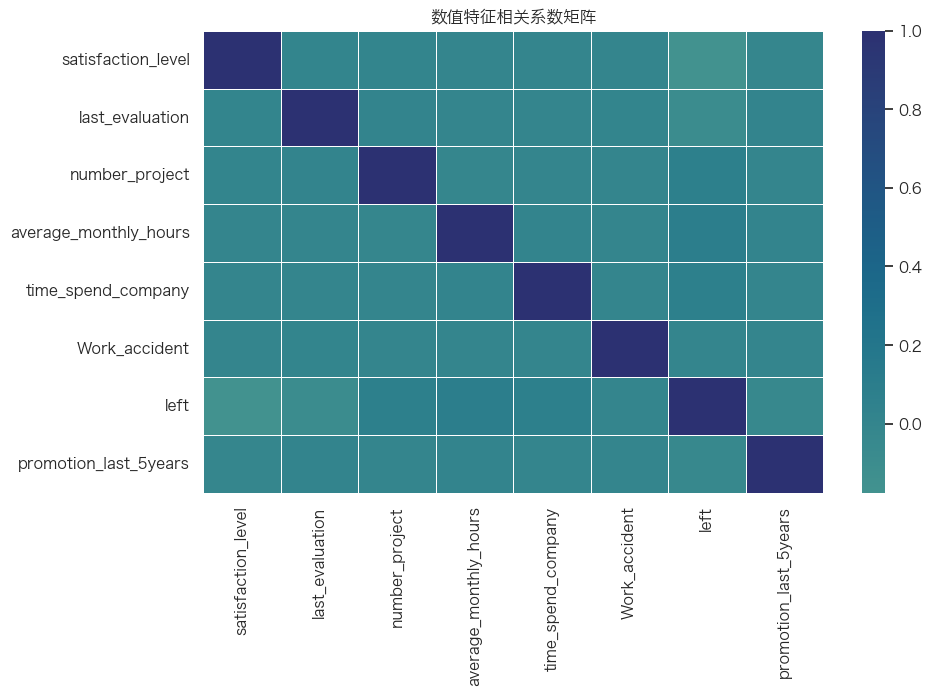

部门离职率: sales
management     0.219853
support        0.232131
RandD          0.234983
product_mng    0.236876
hr             0.238380
marketing      0.240576
IT             0.242404
accounting     0.247852
technical      0.255435
sales          0.256548
Name: left, dtype: float64
工资等级离职率: salary
high      0.131423
low       0.294942
medium    0.208742
Name: left, dtype: float64


In [41]:

num_cols = hr_df_clean.select_dtypes(include="number").columns
corr_matrix = hr_df_clean[num_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap="crest", center=0, linewidths=0.5)
plt.title("数值特征相关系数矩阵")
plt.show()

dept_attrition = hr_df_clean.groupby("sales")["left"].mean().sort_values()
salary_attrition = hr_df_clean.groupby("salary")["left"].mean().sort_index()

print("部门离职率:", dept_attrition)
print("工资等级离职率:", salary_attrition)


## 5. 特征预处理与数据集划分

- 对 `sales`、`salary` 做独热编码
- 8:2 划分训练 / 测试集

In [42]:

X = hr_df_clean.drop(columns=["left"])
y = hr_df_clean["left"]

categorical_features = ["sales", "salary"]
numerical_features = X.columns.difference(categorical_features)

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
category_transformer = Pipeline(steps=[("encoder", OneHotEncoder(drop="first"))])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", category_transformer, categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("训练集大小:", X_train.shape, "测试集大小:", X_test.shape)


训练集大小: (12000, 9) 测试集大小: (3000, 9)


## 6. 基线模型：逻辑回归

- 训练逻辑回归
- 输出准确率、混淆矩阵、Precision/Recall/F1

In [43]:

log_reg_clf = Pipeline(
    steps=[("preprocess", preprocess), ("model", LogisticRegression(max_iter=200))]
)
log_reg_clf.fit(X_train, y_train)

log_pred = log_reg_clf.predict(X_test)
log_proba = log_reg_clf.predict_proba(X_test)[:, 1]

log_acc = accuracy_score(y_test, log_pred)
log_prec = precision_score(y_test, log_pred)
log_rec = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)
log_auc = roc_auc_score(y_test, log_proba)

print(
    f"逻辑回归准确率: {log_acc:.3f}, Precision: {log_prec:.3f}, Recall: {log_rec:.3f}, F1: {log_f1:.3f}, ROC-AUC: {log_auc:.3f}"
)
print("分类报告:", classification_report(y_test, log_pred))
print("混淆矩阵:", confusion_matrix(y_test, log_pred))


逻辑回归准确率: 0.760, Precision: 0.509, Recall: 0.078, F1: 0.135, ROC-AUC: 0.671
分类报告:               precision    recall  f1-score   support

           0       0.77      0.98      0.86      2279
           1       0.51      0.08      0.13       721

    accuracy                           0.76      3000
   macro avg       0.64      0.53      0.50      3000
weighted avg       0.71      0.76      0.69      3000

混淆矩阵: [[2225   54]
 [ 665   56]]


## 7. 提升模型：随机森林 + 交叉验证

- 5 折交叉验证比较 AUC / F1
- 网格搜索调参 (树数量、深度、最小分裂样本)

In [44]:

rf_clf = Pipeline(
    steps=[("preprocess", preprocess), ("model", RandomForestClassifier(random_state=42))]
)

cv_auc = cross_val_score(rf_clf, X, y, cv=5, scoring="roc_auc")
cv_f1 = cross_val_score(rf_clf, X, y, cv=5, scoring="f1")
print(
    f"随机森林 5 折 AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}; F1: {cv_f1.mean():.3f} ± {cv_f1.std():.3f}"
)

param_grid = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [None, 12, 18],
    "model__min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    rf_clf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring="roc_auc",
)

grid_search.fit(X_train, y_train)
print("最佳参数:", grid_search.best_params_)

best_rf = grid_search.best_estimator_
rf_pred = best_rf.predict(X_test)
rf_proba = best_rf.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)

print(
    f"随机森林测试集- 准确率: {rf_acc:.3f}, Precision: {rf_prec:.3f}, Recall: {rf_rec:.3f}, F1: {rf_f1:.3f}, ROC-AUC: {rf_auc:.3f}"
)
print("分类报告:", classification_report(y_test, rf_pred))
print("混淆矩阵:", confusion_matrix(y_test, rf_pred))


随机森林 5 折 AUC: 0.661 ± 0.010; F1: 0.213 ± 0.023
最佳参数: {'model__max_depth': 12, 'model__min_samples_split': 5, 'model__n_estimators': 250}
随机森林测试集- 准确率: 0.764, Precision: 0.559, Recall: 0.086, F1: 0.149, ROC-AUC: 0.663
分类报告:               precision    recall  f1-score   support

           0       0.77      0.98      0.86      2279
           1       0.56      0.09      0.15       721

    accuracy                           0.76      3000
   macro avg       0.67      0.53      0.51      3000
weighted avg       0.72      0.76      0.69      3000

混淆矩阵: [[2230   49]
 [ 659   62]]


## 8. 特征重要性与模型解释

- 提取树模型 `feature_importances_`
- 讨论满意度、工时、工龄、晋升、工资等影响

特征重要性(前10):                   feature  importance
5      satisfaction_level    0.255158
1   average_monthly_hours    0.207306
2         last_evaluation    0.190763
6      time_spend_company    0.089502
3          number_project    0.066951
16             salary_low    0.045989
0           Work_accident    0.016481
17          salary_medium    0.014296
13            sales_sales    0.012046
7             sales_RandD    0.011817


/var/folders/wg/9ryslwv550l9xnt72kk5m_nr0000gn/T/ipykernel_39224/1380674375.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(12), x="importance", y="feature", palette="viridis")


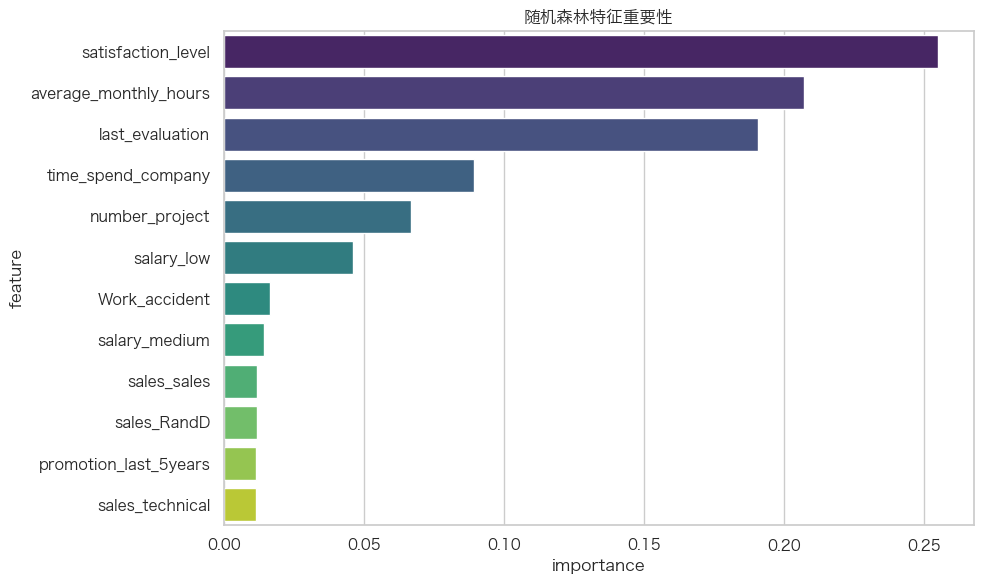

In [45]:

# 获取特征名顺序
num_features = numerical_features.tolist()
cat_encoder = best_rf.named_steps["preprocess"].named_transformers_["cat"].named_steps[
    "encoder"
]
cat_features = cat_encoder.get_feature_names_out(categorical_features)
feature_names = num_features + list(cat_features)

rf_model = best_rf.named_steps["model"]
importance_df = pd.DataFrame(
    {"feature": feature_names, "importance": rf_model.feature_importances_}
).sort_values("importance", ascending=False)

print("特征重要性(前10):", importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(12), x="importance", y="feature", palette="viridis")
plt.title("随机森林特征重要性")
plt.tight_layout()
plt.show()


## 9. ROC 曲线对比

- 绘制逻辑回归与随机森林 ROC 曲线并标注 AUC

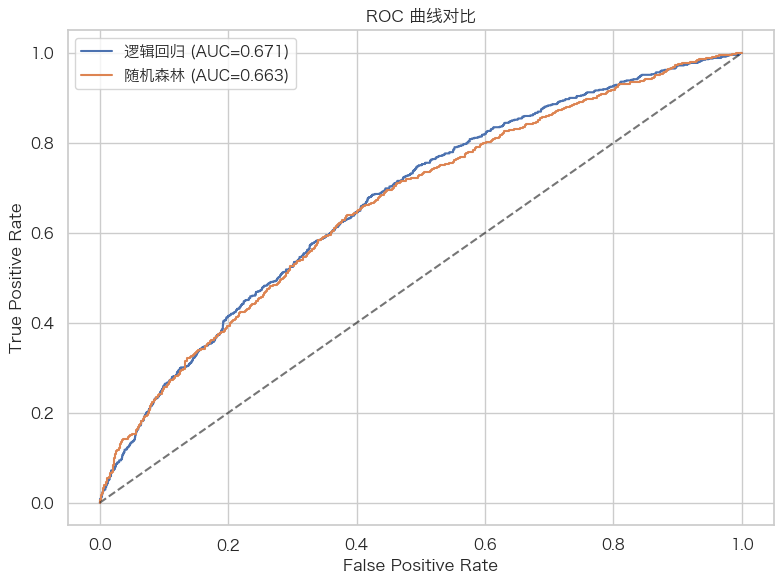

In [46]:

log_fpr, log_tpr, _ = roc_curve(y_test, log_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(8, 6))
plt.plot(log_fpr, log_tpr, label=f"逻辑回归 (AUC={log_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"随机森林 (AUC={rf_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC 曲线对比")
plt.legend()
plt.tight_layout()
plt.show()
